<a href="https://colab.research.google.com/github/Akanshajoshiiii/SpeechLAB/blob/main/Copy_of_Lab4_Baum_Welch_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

given :obs seq , how too adjust   
lambda=(A,B,pi) to maximise likelihood  
P(o|lambda)

In [ ]:
import numpy as np
transition=np.array([[0.3,0.7],[0.9,0.1]])
emission=np.array([[0.4,0.6],[0.5,0.5]])
initial=np.array([0.85,0.15])
states = ['s','t']
states_dic = {'s':0, 't':1}
sequence_syms = {'A':0,'B':1}
sequence='ABBA'

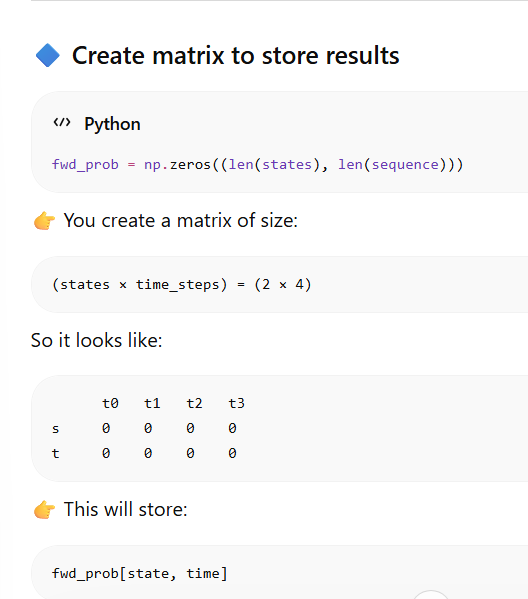

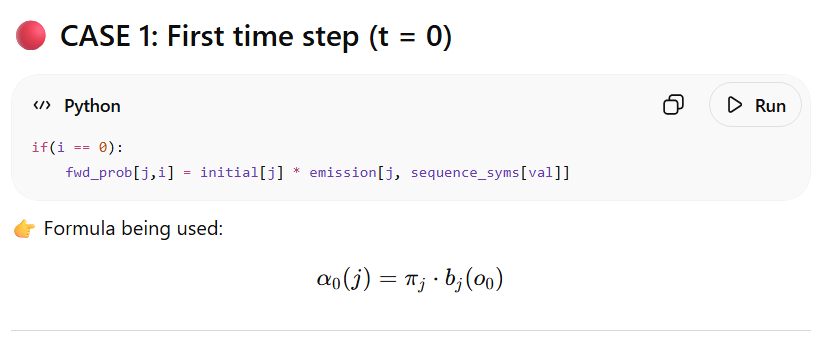

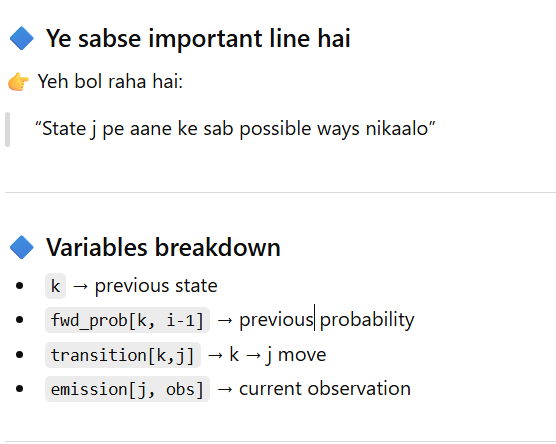

In [ ]:
def forward_prob():
  fwd_prob=np.zeros((len(states),len(sequence)))
  i=0#initialising the timestamp
  for val in sequence:
    if(i<len(sequence)):
      for j in range(len(states)):
        if(i==0):
          fwd_prob[j,i]=initial[j]*emission[j,sequence_syms[val]]#probability at timestamp 0
        else:
          values=[fwd_prob[k, i - 1] * emission[j, sequence_syms[val]] * transition[k, j] for k in
                            range(len(states))]
          fwd_prob[j,i]=sum(values)
      i=i+1
  return fwd_prob


In [ ]:
import numpy as np

def backward_prob():
    node_values_bwd = np.zeros((len(states), len(sequence)))
    node_values_bwd[:, -1] = 1
    for i in range(len(sequence) - 2, -1, -1):
        for j in range(len(states)):
            values = [
                node_values_bwd[k, i+1] *
                emission[k, sequence_syms[sequence[i+1]]] *
                transition[j, k]
                for k in range(len(states))
            ]
            node_values_bwd[j, i] = sum(values)

    return node_values_bwd

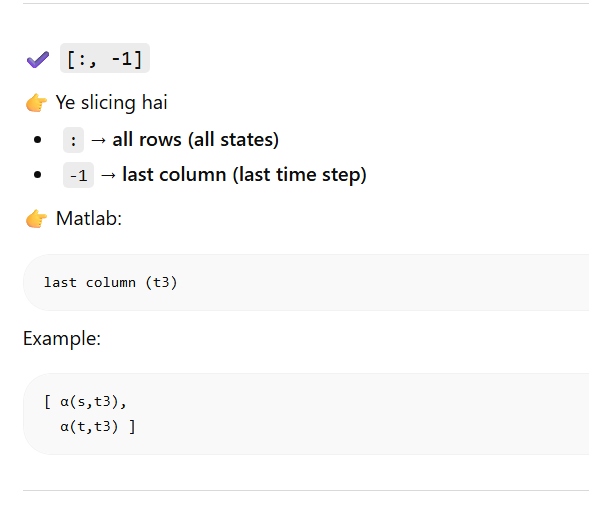

In [ ]:
forward_val=np.sum(forward_prob()[:,-1])
forward=forward_prob()
backward=backward_prob()

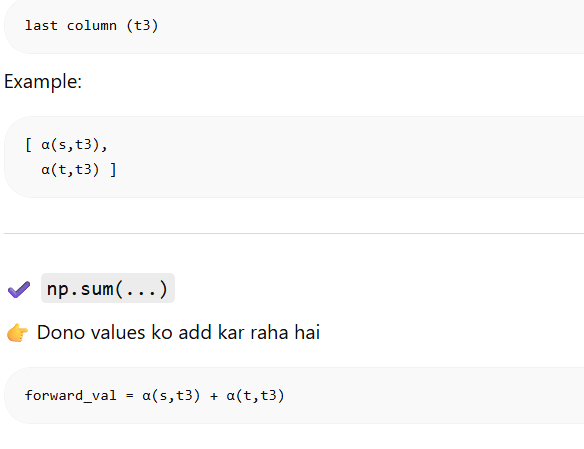

In [ ]:
def shee_probs(forward, backward, forward_val):

    shee_probabilities = np.zeros((len(states), len(sequence)-1, len(states))) #(current_state, time, next_state)

    for i in range(len(sequence)-1):
        for j in range(len(states)):
            for k in range(len(states)):
                shee_probabilities[j,i,k] = ( forward[j,i] * backward[k,i+1] * transition[j,k] * emission[k,sequence_syms[sequence[i+1]]] )/ forward_val
    return shee_probabilities


In [ ]:
shee_probs(forward, backward, forward_val)

array([[[0.24547543, 0.57398969],
        [0.15129432, 0.25662808],
        [0.17849939, 0.52062321]],

       [[0.16244697, 0.01808791],
        [0.54782827, 0.04424933],
        [0.26418504, 0.03669237]]])

In [ ]:
def eta_prob():
  shee_probabilities=shee_probs(forward,backward,forward_val)
  eta_probabilities=np.zeros((len(states),len(sequence)-1))
  for i in range(len(sequence)-1):
    for j in range(len(states)):
      eta_probabilities[j,i]=sum([shee_probabilities[j,i,k] for k in range(len(states))])
  return eta_probabilities

In [ ]:
eta_prob()

array([[0.81946511, 0.4079224 , 0.69912259],
       [0.18053489, 0.5920776 , 0.30087741]])

WAP to calculate updated transition probabilities using shee probabilities.

np.zeros((len(states), len(states)))

In [ ]:
def updated_transition_prob():
  shee_probabilities=shee_probs(forward,backward,forward_val)
  eta_probabilities=eta_prob()
  updated_transition=np.zeros((2,2))
  for i in range(len(states)):
    for j in range(len(states)):
      updated_transition[i,j]=np.sum([shee_probabilities[i,k,j] for k in range(len(sequence)-1)])/np.sum([eta_probabilities[i,k] for k in range(len(sequence)-1)]) #shee/eta
  return updated_transition

In [ ]:
updated_transition_prob()

array([[0.29860686, 0.70139314],
       [0.90774985, 0.09225015]])

WAP to calculate updated initial probabilities and observation probabilities using eta probabilities.

In [ ]:
def updated_initial_prob():
    eta_probabilities = eta_prob()

    updated_pi = np.zeros(len(states))

    for i in range(len(states)):
        updated_pi[i] = eta_probabilities[i, 0]

    return updated_pi